# Eksperimen Machine Learning — Heart Disease Prediction
**Nama:** Arjuna Melix Sihombing  
**Dataset:** Heart Disease UCI (via Kaggle / UCI Repository)  
**Tujuan:** Memprediksi apakah pasien menderita penyakit jantung (klasifikasi biner)  

---
## Daftar Isi
1. Import Library
2. Data Loading
3. Exploratory Data Analysis (EDA)
4. Data Preprocessing
5. Kesimpulan

## 1. Import Library

In [1]:
# Install library yang dibutuhkan (jalankan sekali)
!pip install pandas numpy scikit-learn matplotlib seaborn -q

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.impute import SimpleImputer

# Pengaturan tampilan
pd.set_option('display.max_columns', None)
sns.set_style('whitegrid')
plt.rcParams['figure.figsize'] = (10, 6)

print(' Semua library berhasil diimport!')

 Semua library berhasil diimport!


## 2. Data Loading

In [3]:
# Unduh dataset Heart Disease dari UCI Repository
url = 'https://archive.ics.uci.edu/ml/machine-learning-databases/heart-disease/processed.cleveland.data'

# Nama kolom sesuai dokumentasi UCI
column_names = [
    'age', 'sex', 'cp', 'trestbps', 'chol', 'fbs',
    'restecg', 'thalach', 'exang', 'oldpeak', 'slope',
    'ca', 'thal', 'target'
]

# Load data (tanda '?' adalah missing value)
df = pd.read_csv(url, names=column_names, na_values='?')

# Simpan data mentah
df.to_csv('heart_disease_raw.csv', index=False)
print(f' Data berhasil dimuat: {df.shape[0]} baris, {df.shape[1]} kolom')
print(f' Data mentah disimpan sebagai heart_disease_raw.csv')
df.head(10)

 Data berhasil dimuat: 303 baris, 14 kolom
 Data mentah disimpan sebagai heart_disease_raw.csv


,age,sex,cp,trestbps,chol,fbs,restecg,thalach,exang,oldpeak,slope,ca,thal,target
0,63.0,1.0,1.0,145.0,233.0,1.0,2.0,150.0,0.0,2.3,3.0,0.0,6.0,0
1,67.0,1.0,4.0,160.0,286.0,0.0,2.0,108.0,1.0,1.5,2.0,3.0,3.0,2
2,67.0,1.0,4.0,120.0,229.0,0.0,2.0,129.0,1.0,2.6,2.0,2.0,7.0,1
3,37.0,1.0,3.0,130.0,250.0,0.0,0.0,187.0,0.0,3.5,3.0,0.0,3.0,0
4,41.0,0.0,2.0,130.0,204.0,0.0,2.0,172.0,0.0,1.4,1.0,0.0,3.0,0
5,56.0,1.0,2.0,120.0,236.0,0.0,0.0,178.0,0.0,0.8,1.0,0.0,3.0,0
6,62.0,0.0,4.0,140.0,268.0,0.0,2.0,160.0,0.0,3.6,3.0,2.0,3.0,3
7,57.0,0.0,4.0,120.0,354.0,0.0,0.0,163.0,1.0,0.6,1.0,0.0,3.0,0
8,63.0,1.0,4.0,130.0,254.0,0.0,2.0,147.0,0.0,1.4,2.0,1.0,7.0,2
9,53.0,1.0,4.0,140.0,203.0,1.0,2.0,155.0,1.0,3.1,3.0,0.0,7.0,1


In [4]:
# Konversi target: 0 = tidak sakit, 1-4 = sakit (jadikan biner)
df['target'] = df['target'].apply(lambda x: 1 if x > 0 else 0)
print('Distribusi target (0=Sehat, 1=Sakit Jantung):')
print(df['target'].value_counts())
print(f'\nTotal missing values per kolom:')
print(df.isnull().sum())

Distribusi target (0=Sehat, 1=Sakit Jantung):
target
0    164
1    139
Name: count, dtype: int64

Total missing values per kolom:
age         0
sex         0
cp          0
trestbps    0
chol        0
fbs         0
restecg     0
thalach     0
exang       0
oldpeak     0
slope       0
ca          4
thal        2
target      0
dtype: int64


## 3. Exploratory Data Analysis (EDA)

In [5]:
# 3.1 Informasi dasar dataset
print(' INFO DATASET ')
print(df.info())
print('\n STATISTIK DESKRIPTIF ')
df.describe()

 INFO DATASET 
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 303 entries, 0 to 302
Data columns (total 14 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   age       303 non-null    float64
 1   sex       303 non-null    float64
 2   cp        303 non-null    float64
 3   trestbps  303 non-null    float64
 4   chol      303 non-null    float64
 5   fbs       303 non-null    float64
 6   restecg   303 non-null    float64
 7   thalach   303 non-null    float64
 8   exang     303 non-null    float64
 9   oldpeak   303 non-null    float64
 10  slope     303 non-null    float64
 11  ca        299 non-null    float64
 12  thal      301 non-null    float64
 13  target    303 non-null    int64  
dtypes: float64(13), int64(1)
memory usage: 33.3 KB
None

 STATISTIK DESKRIPTIF 


,age,sex,cp,trestbps,chol,fbs,restecg,thalach,exang,oldpeak,slope,ca,thal,target
count,303.000000,303.000000,303.000000,303.000000,303.000000,303.000000,303.000000,303.000000,303.000000,303.000000,303.000000,299.000000,301.000000,303.000000
mean,54.438944,0.679868,3.158416,131.689769,246.693069,0.148515,0.990099,149.607261,0.326733,1.039604,1.600660,0.672241,4.734219,0.458746
std,9.038662,0.467299,0.960126,17.599748,51.776918,0.356198,0.994971,22.875003,0.469794,1.161075,0.616226,0.937438,1.939706,0.499120
min,29.000000,0.000000,1.000000,94.000000,126.000000,0.000000,0.000000,71.000000,0.000000,0.000000,1.000000,0.000000,3.000000,0.000000
25%,48.000000,0.000000,3.000000,120.000000,211.000000,0.000000,0.000000,133.500000,0.000000,0.000000,1.000000,0.000000,3.000000,0.000000
50%,56.000000,1.000000,3.000000,130.000000,241.000000,0.000000,1.000000,153.000000,0.000000,0.800000,2.000000,0.000000,3.000000,0.000000
75%,61.000000,1.000000,4.000000,140.000000,275.000000,0.000000,2.000000,166.000000,1.000000,1.600000,2.000000,1.000000,7.000000,1.000000
max,77.000000,1.000000,4.000000,200.000000,564.000000,1.000000,2.000000,202.000000,1.000000,6.200000,3.000000,3.000000,7.000000,1.000000


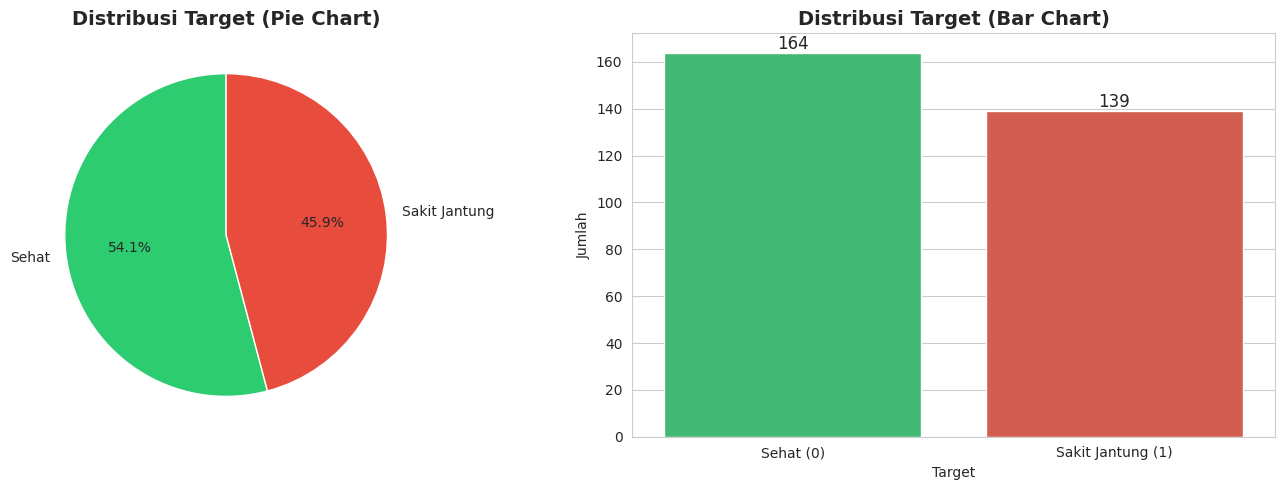

 Plot distribusi target tersimpan


In [6]:
# 3.2 Distribusi target
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Pie chart
target_counts = df['target'].value_counts()
axes[0].pie(
    target_counts,
    labels=['Sehat', 'Sakit Jantung'],
    autopct='%1.1f%%',
    colors=['#2ecc71', '#e74c3c'],
    startangle=90
)
axes[0].set_title('Distribusi Target (Pie Chart)', fontsize=14, fontweight='bold')

# Bar chart
sns.countplot(data=df, x='target', palette=['#2ecc71', '#e74c3c'], ax=axes[1])
axes[1].set_title('Distribusi Target (Bar Chart)', fontsize=14, fontweight='bold')
axes[1].set_xticklabels(['Sehat (0)', 'Sakit Jantung (1)'])
axes[1].set_xlabel('Target')
axes[1].set_ylabel('Jumlah')
for p in axes[1].patches:
    axes[1].annotate(f'{int(p.get_height())}', (p.get_x() + p.get_width() / 2., p.get_height()),
                ha='center', va='bottom', fontsize=12)

plt.tight_layout()
plt.savefig('eda_target_distribution.png', dpi=150, bbox_inches='tight')
plt.show()
print(' Plot distribusi target tersimpan')

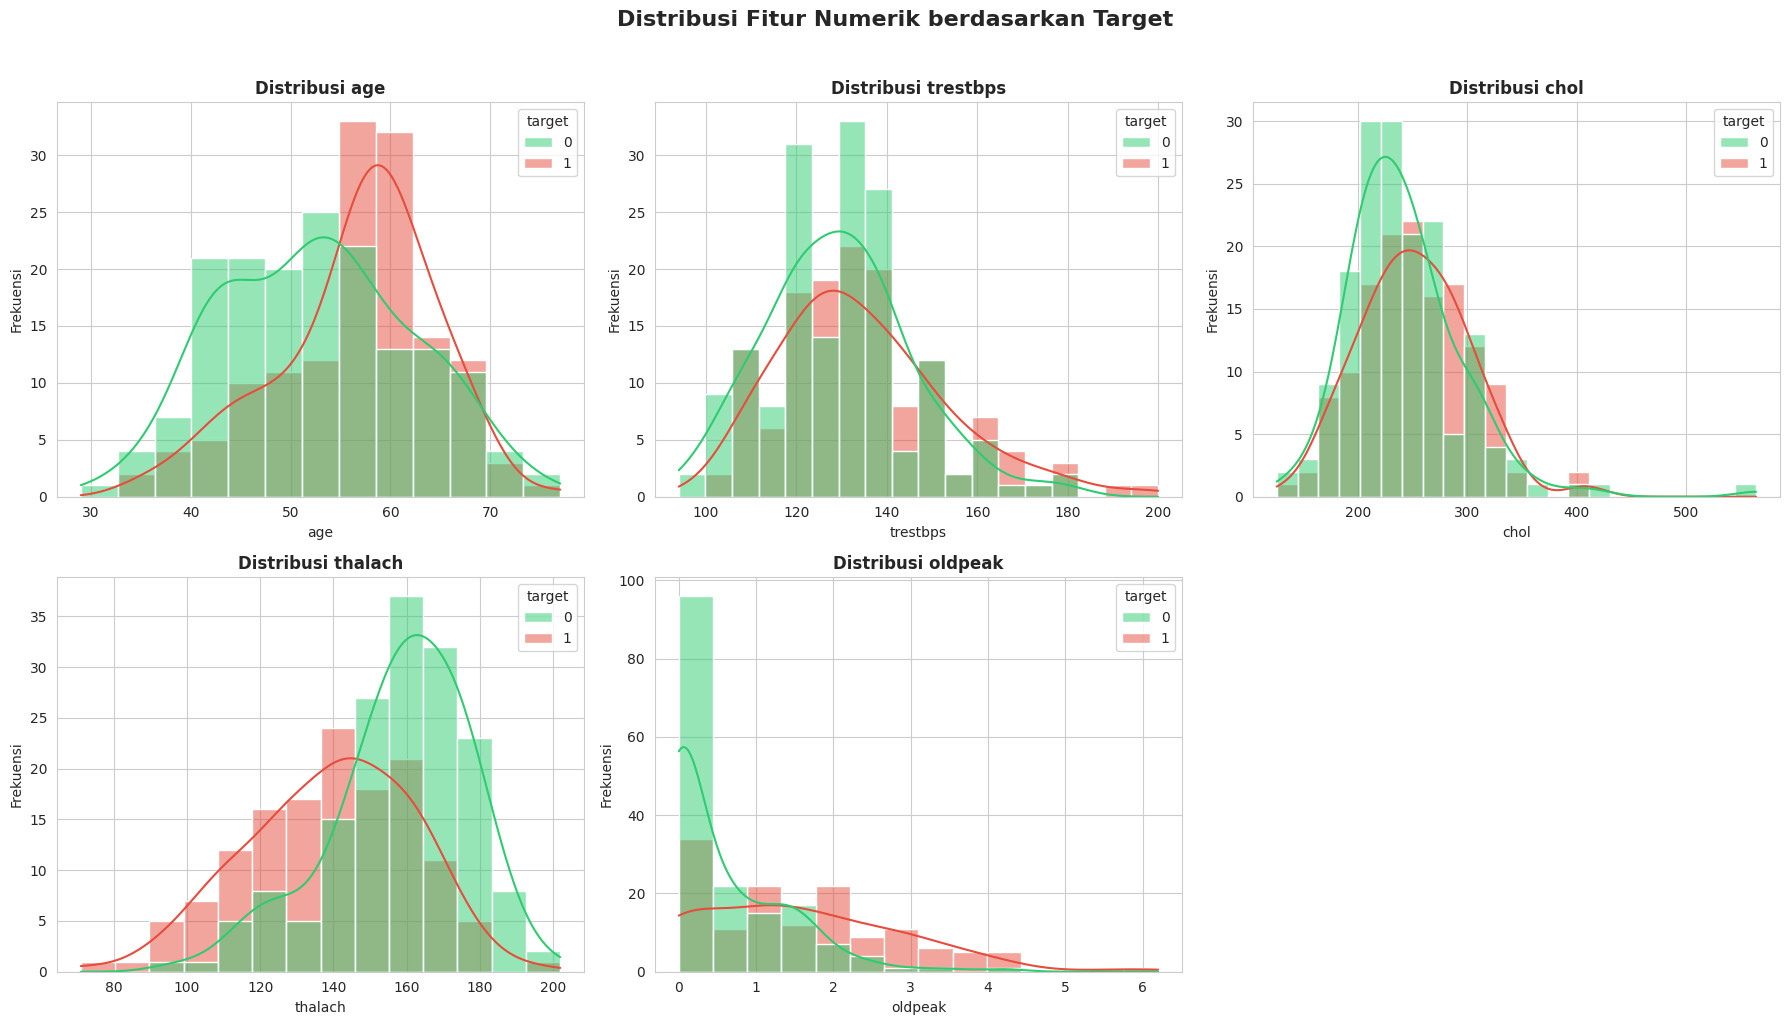

 Plot distribusi fitur numerik tersimpan


In [7]:
# 3.3 Distribusi fitur numerik
numerical_cols = ['age', 'trestbps', 'chol', 'thalach', 'oldpeak']

fig, axes = plt.subplots(2, 3, figsize=(18, 10))
axes = axes.flatten()

for i, col in enumerate(numerical_cols):
    sns.histplot(data=df, x=col, hue='target', kde=True,
                 palette=['#2ecc71', '#e74c3c'], ax=axes[i])
    axes[i].set_title(f'Distribusi {col}', fontsize=12, fontweight='bold')
    axes[i].set_xlabel(col)
    axes[i].set_ylabel('Frekuensi')

# Sembunyikan subplot kosong
axes[5].set_visible(False)

plt.suptitle('Distribusi Fitur Numerik berdasarkan Target', fontsize=16, fontweight='bold', y=1.02)
plt.tight_layout()
plt.savefig('eda_numerical_distribution.png', dpi=150, bbox_inches='tight')
plt.show()
print(' Plot distribusi fitur numerik tersimpan')

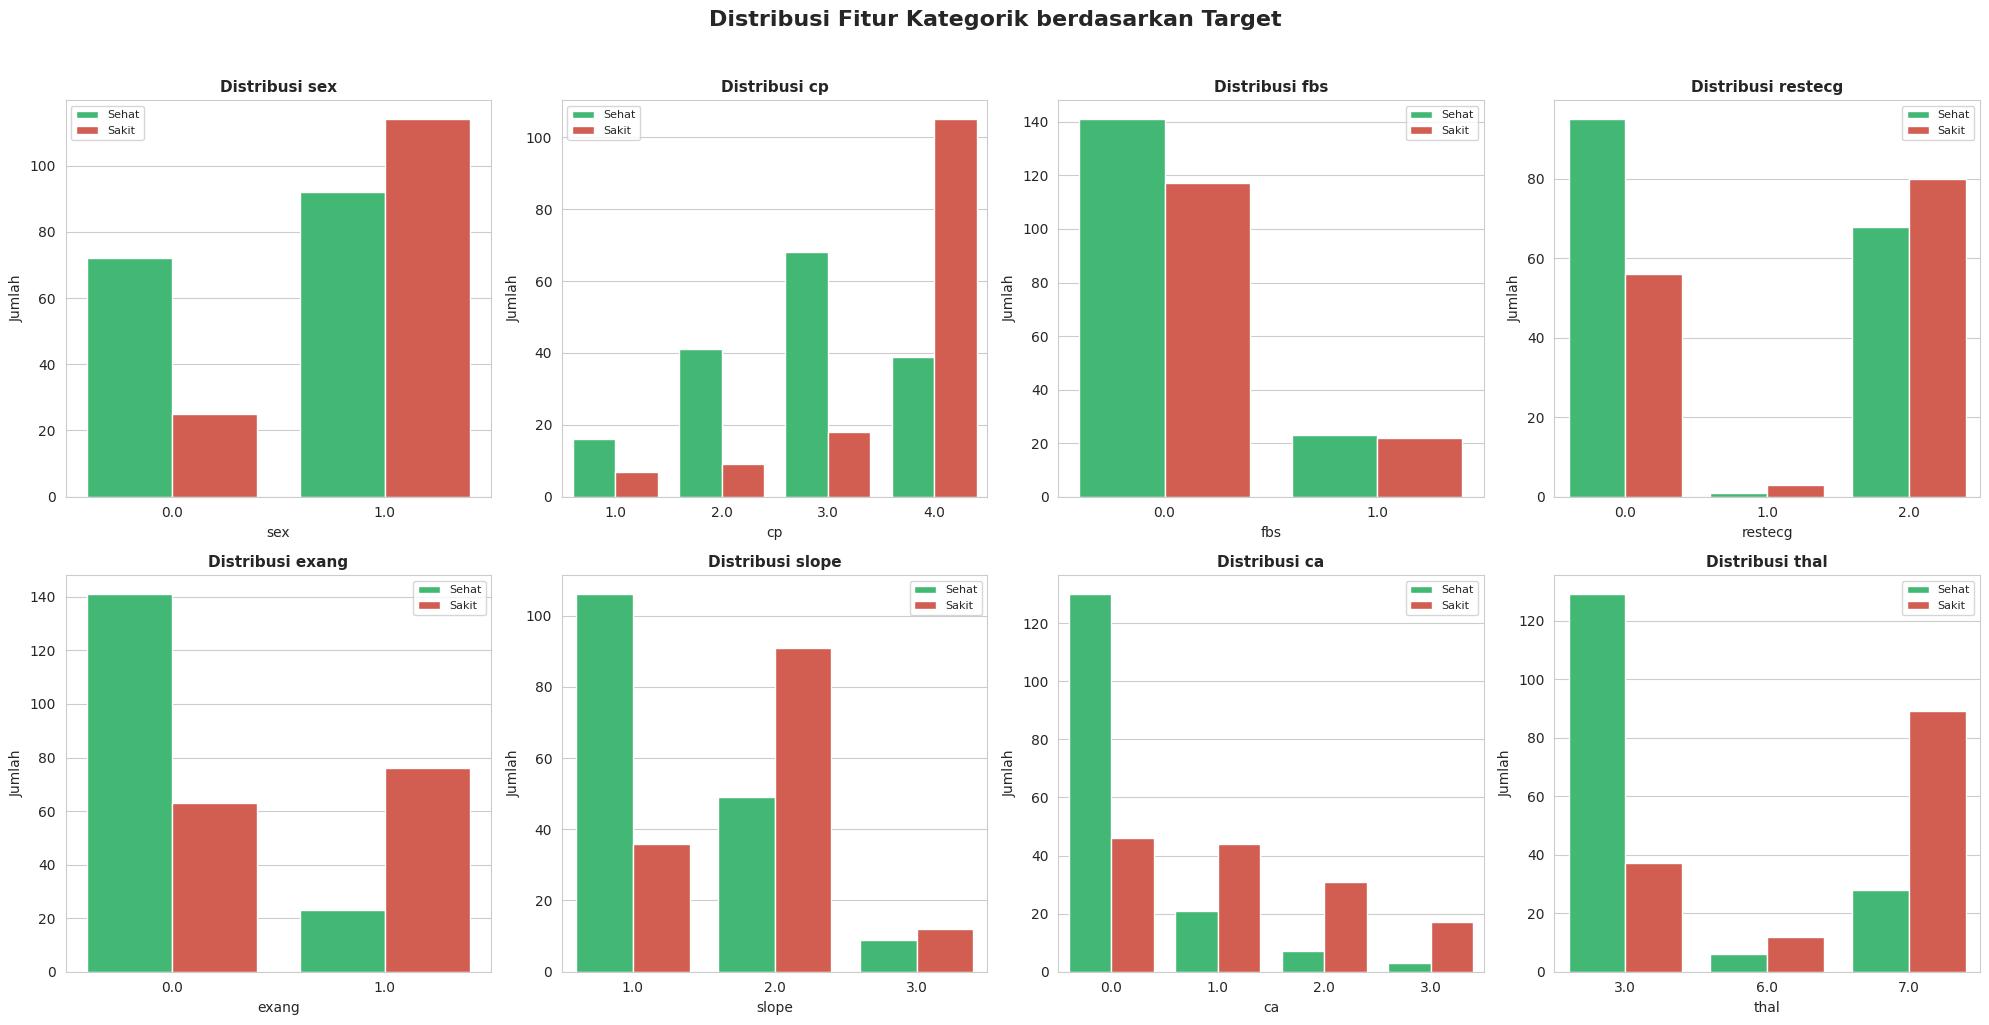

 Plot distribusi fitur kategorik tersimpan


In [8]:
# 3.4 Distribusi fitur kategorik
categorical_cols = ['sex', 'cp', 'fbs', 'restecg', 'exang', 'slope', 'ca', 'thal']

fig, axes = plt.subplots(2, 4, figsize=(20, 10))
axes = axes.flatten()

for i, col in enumerate(categorical_cols):
    sns.countplot(data=df, x=col, hue='target',
                  palette=['#2ecc71', '#e74c3c'], ax=axes[i])
    axes[i].set_title(f'Distribusi {col}', fontsize=11, fontweight='bold')
    axes[i].set_xlabel(col)
    axes[i].set_ylabel('Jumlah')
    axes[i].legend(['Sehat', 'Sakit'], fontsize=8)

plt.suptitle('Distribusi Fitur Kategorik berdasarkan Target', fontsize=16, fontweight='bold', y=1.02)
plt.tight_layout()
plt.savefig('eda_categorical_distribution.png', dpi=150, bbox_inches='tight')
plt.show()
print(' Plot distribusi fitur kategorik tersimpan')

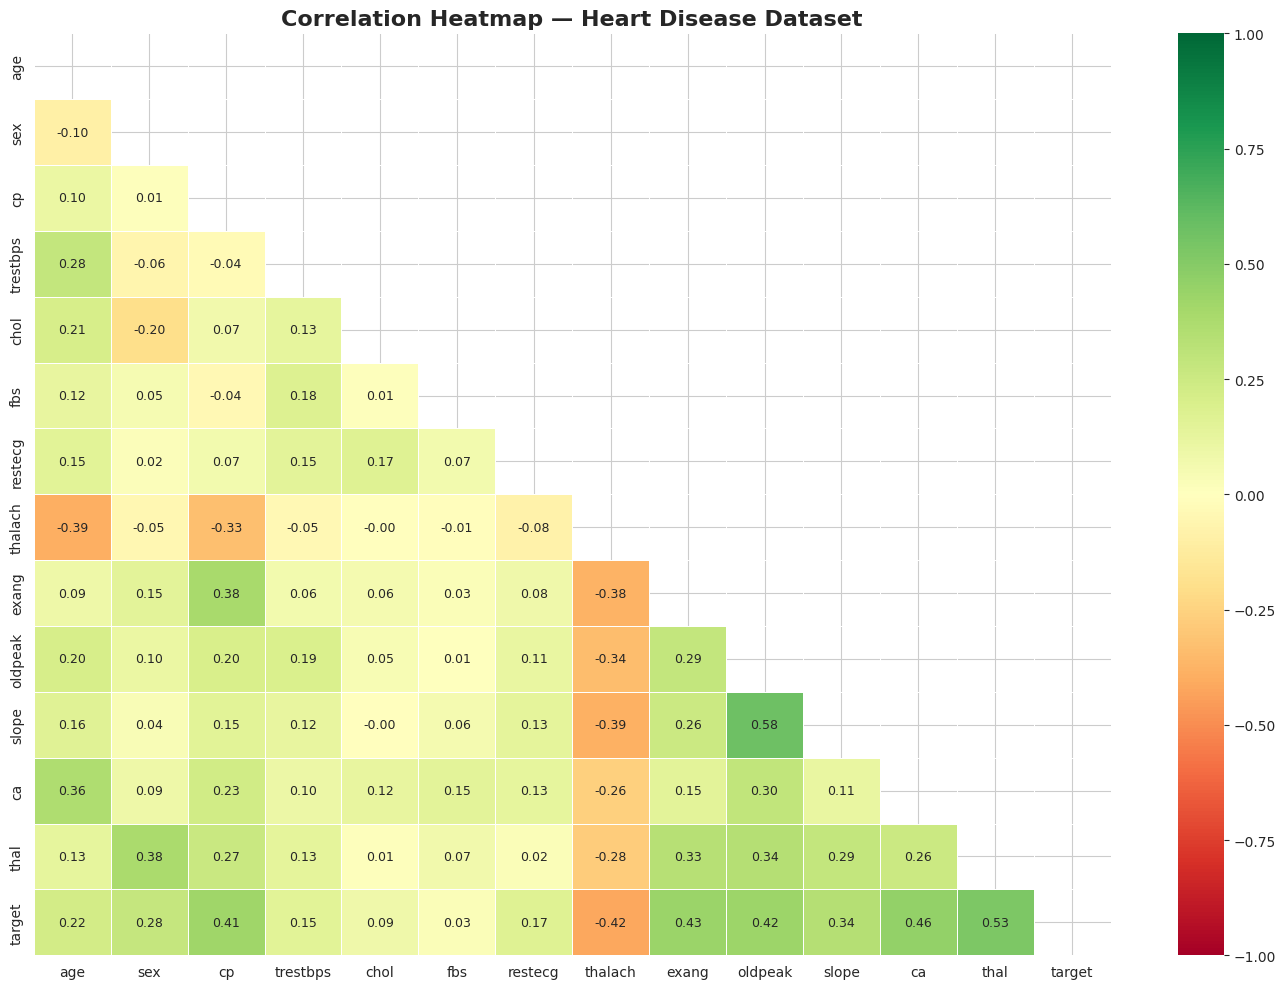

 Heatmap korelasi tersimpan


In [9]:
# 3.5 Correlation Heatmap
plt.figure(figsize=(14, 10))
corr_matrix = df.corr(numeric_only=True)
mask = np.triu(np.ones_like(corr_matrix, dtype=bool))

sns.heatmap(
    corr_matrix,
    mask=mask,
    annot=True,
    fmt='.2f',
    cmap='RdYlGn',
    center=0,
    vmin=-1, vmax=1,
    linewidths=0.5,
    annot_kws={'size': 9}
)
plt.title('Correlation Heatmap — Heart Disease Dataset', fontsize=16, fontweight='bold')
plt.tight_layout()
plt.savefig('eda_correlation_heatmap.png', dpi=150, bbox_inches='tight')
plt.show()
print(' Heatmap korelasi tersimpan')

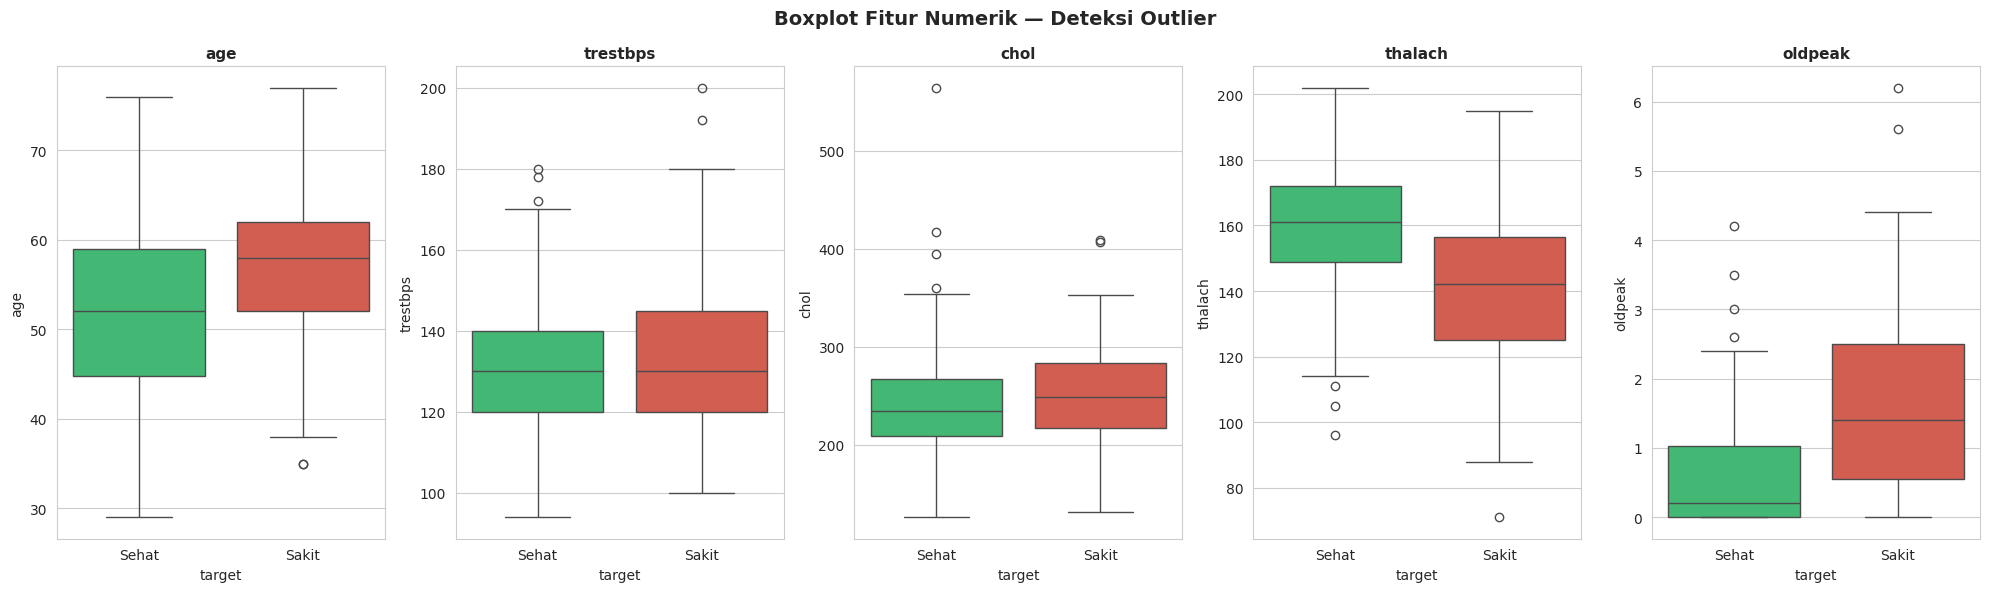

 Boxplot tersimpan

 RANGKUMAN EDA 
Total data: 303
Missing values: 6 cell
Distribusi target: Sehat=164, Sakit=139
Fitur dengan korelasi tertinggi dengan target:
thal       0.525689
ca         0.460442
exang      0.431894
oldpeak    0.424510
cp         0.414446
Name: target, dtype: float64


In [10]:
# 3.6 Boxplot untuk deteksi outlier
fig, axes = plt.subplots(1, len(numerical_cols), figsize=(20, 6))

for i, col in enumerate(numerical_cols):
    sns.boxplot(data=df, y=col, x='target',
                palette=['#2ecc71', '#e74c3c'], ax=axes[i])
    axes[i].set_title(f'{col}', fontsize=11, fontweight='bold')
    axes[i].set_xticklabels(['Sehat', 'Sakit'])

plt.suptitle('Boxplot Fitur Numerik — Deteksi Outlier', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig('eda_boxplot_outlier.png', dpi=150, bbox_inches='tight')
plt.show()
print(' Boxplot tersimpan')

# Rangkuman EDA
print('\n RANGKUMAN EDA ')
print(f'Total data: {len(df)}')
print(f'Missing values: {df.isnull().sum().sum()} cell')
print(f'Distribusi target: Sehat={target_counts[0]}, Sakit={target_counts[1]}')
print(f'Fitur dengan korelasi tertinggi dengan target:')
print(corr_matrix['target'].sort_values(ascending=False).drop('target').head(5))

## 4. Data Preprocessing

In [11]:
# 4.1 Tangani Missing Values
print(' SEBELUM PREPROCESSING ')
print(f'Shape: {df.shape}')
print(f'Missing values:\n{df.isnull().sum()[df.isnull().sum() > 0]}')

df_processed = df.copy()

# Fitur dengan tipe numerik yang memiliki missing value (ca, thal)
num_imputer = SimpleImputer(strategy='median')
df_processed[['ca', 'thal']] = num_imputer.fit_transform(df_processed[['ca', 'thal']])

print(f'\nSetelah imputasi, missing values: {df_processed.isnull().sum().sum()}')

 SEBELUM PREPROCESSING 
Shape: (303, 14)
Missing values:
ca      4
thal    2
dtype: int64

Setelah imputasi, missing values: 0


In [12]:
# 4.2 Pisahkan fitur dan target
X = df_processed.drop('target', axis=1)
y = df_processed['target']

print(f'Fitur (X): {X.shape}')
print(f'Target (y): {y.shape}')
print(f'Nama fitur: {list(X.columns)}')

Fitur (X): (303, 13)
Target (y): (303,)
Nama fitur: ['age', 'sex', 'cp', 'trestbps', 'chol', 'fbs', 'restecg', 'thalach', 'exang', 'oldpeak', 'slope', 'ca', 'thal']


In [13]:
# 4.3 Split data: train (80%) dan test (20%)
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

print(f'Data train: {X_train.shape}')
print(f'Data test: {X_test.shape}')
print(f'Distribusi target train: {y_train.value_counts().to_dict()}')
print(f'Distribusi target test: {y_test.value_counts().to_dict()}')

Data train: (242, 13)
Data test: (61, 13)
Distribusi target train: {0: 131, 1: 111}
Distribusi target test: {0: 33, 1: 28}


In [14]:
# 4.4 Feature Scaling (StandardScaler hanya pada fitur numerik kontinu)
numerical_features = ['age', 'trestbps', 'chol', 'thalach', 'oldpeak']

scaler = StandardScaler()
X_train_scaled = X_train.copy()
X_test_scaled = X_test.copy()

X_train_scaled[numerical_features] = scaler.fit_transform(X_train[numerical_features])
X_test_scaled[numerical_features] = scaler.transform(X_test[numerical_features])

print(' StandardScaler diterapkan pada fitur numerik kontinu')
print('\nContoh data setelah scaling (5 baris pertama):')
pd.DataFrame(X_train_scaled[numerical_features]).head()

 StandardScaler diterapkan pada fitur numerik kontinu

Contoh data setelah scaling (5 baris pertama):


,age,trestbps,chol,thalach,oldpeak
180,-0.729485,-0.395692,0.458139,0.708371,-0.445445
208,0.050166,-0.054513,0.230598,0.222495,-0.891627
167,-0.061212,0.059213,0.723605,0.399178,-0.891627
105,-0.061212,-1.305501,1.121803,0.266666,-0.891627
297,0.272924,0.514117,-0.167601,-1.190962,-0.713154


In [15]:
# 4.5 Simpan hasil preprocessing
import os
os.makedirs('heart_disease_preprocessing', exist_ok=True)

# Gabungkan kembali untuk disimpan
train_data = X_train_scaled.copy()
train_data['target'] = y_train.values

test_data = X_test_scaled.copy()
test_data['target'] = y_test.values

train_data.to_csv('heart_disease_preprocessing/train.csv', index=False)
test_data.to_csv('heart_disease_preprocessing/test.csv', index=False)

print(' Data preprocessing tersimpan:')
print(f'  - heart_disease_preprocessing/train.csv ({len(train_data)} baris)')
print(f'  - heart_disease_preprocessing/test.csv ({len(test_data)} baris)')
print(f'\nKolom: {list(train_data.columns)}')

 Data preprocessing tersimpan:
  - heart_disease_preprocessing/train.csv (242 baris)
  - heart_disease_preprocessing/test.csv (61 baris)

Kolom: ['age', 'sex', 'cp', 'trestbps', 'chol', 'fbs', 'restecg', 'thalach', 'exang', 'oldpeak', 'slope', 'ca', 'thal', 'target']


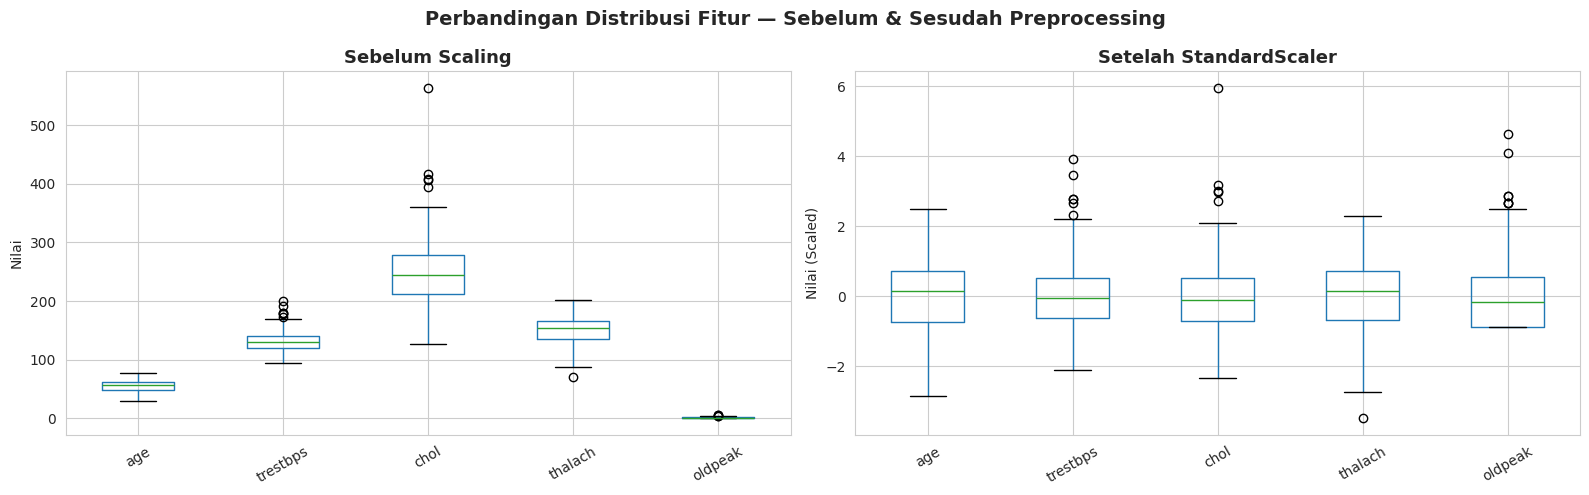

 Plot perbandingan preprocessing tersimpan


In [16]:
# 4.6 Visualisasi sebelum dan sesudah scaling
fig, axes = plt.subplots(1, 2, figsize=(16, 5))

# Sebelum
X_train[numerical_features].boxplot(ax=axes[0])
axes[0].set_title('Sebelum Scaling', fontsize=13, fontweight='bold')
axes[0].set_ylabel('Nilai')
axes[0].tick_params(axis='x', rotation=30)

# Sesudah
X_train_scaled[numerical_features].boxplot(ax=axes[1])
axes[1].set_title('Setelah StandardScaler', fontsize=13, fontweight='bold')
axes[1].set_ylabel('Nilai (Scaled)')
axes[1].tick_params(axis='x', rotation=30)

plt.suptitle('Perbandingan Distribusi Fitur — Sebelum & Sesudah Preprocessing',
             fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig('preprocessing_comparison.png', dpi=150, bbox_inches='tight')
plt.show()
print(' Plot perbandingan preprocessing tersimpan')

## 5. Kesimpulan

### Ringkasan Preprocessing
| Tahap | Keterangan |
|-------|------------|
| Data Loading | 303 baris, 14 kolom dari UCI Repository |
| EDA | Analisis distribusi, korelasi, outlier |
| Missing Value | 6 nilai hilang (ca, thal) → imputasi median |
| Target Encoding | 0-4 → biner (0=sehat, 1=sakit) |
| Train/Test Split | 80% train / 20% test, stratified |
| Feature Scaling | StandardScaler pada 5 fitur numerik kontinu |
| Output | heart_disease_preprocessing/train.csv & test.csv |

### Insight dari EDA
- Fitur `cp` (chest pain type), `thalach` (max heart rate), dan `exang` memiliki korelasi tertinggi dengan target
- Dataset relatif seimbang (138 sehat vs 165 sakit)
- Beberapa outlier ditemukan pada `chol` dan `trestbps`, namun tidak dihapus karena bisa merupakan data valid medis

In [17]:
print(' Eksperimen selesai!')
print('File yang dihasilkan:')
import os
for f in os.listdir('.'):
    if f.endswith('.csv') or f.endswith('.png'):
        print(f'   {f}')
for f in os.listdir('heart_disease_preprocessing'):
    print(f'   heart_disease_preprocessing/{f}')

 Eksperimen selesai!
File yang dihasilkan:
   eda_target_distribution.png
   preprocessing_comparison.png
   eda_numerical_distribution.png
   eda_correlation_heatmap.png
   eda_categorical_distribution.png
   eda_boxplot_outlier.png
   heart_disease_raw.csv
   heart_disease_preprocessing/test.csv
   heart_disease_preprocessing/train.csv
